This notebook is meant for developing/testing code related to the blazar-DESI cross-correlation project

In [ ]:
from astropy.coordinates import SkyCoord
from astropy.table import Table 
import matplotlib.pyplot as plt
from astropy import units as u 
from astropy.io import fits
from tqdm import tqdm 
import healpy as hp 
import numpy as np
import scipy 

In [2]:
def sky_plotter(fits_file, nside):
    fname = fits_file.split('.')[0]
    data = fits.open(fits_file)[1].data
    ra = data['ra']
    dec = data['dec']
    
    gal_coords = np.empty((len(ra), 2))
    icrs_coords = SkyCoord(ra = ra * u.degree, dec = dec * u.degree, frame = 'icrs')
    gal_coords[:, 0] = icrs_coords.galactic.l.to(u.deg).value
    gal_coords[:, 1] = icrs_coords.galactic.b.to(u.deg).value
    np.save(fname + "_gal_coords.npy", gal_coords)
    
    pix = hp.pixelfunc.ang2pix(nside, gal_coords[:, 0], gal_coords[:, 1], lonlat = True)
    npix = hp.nside2npix(nside)
    map_ = np.zeros(npix)
    map_.dtype = 'int'
    map_[pix] = int(1)
    hp.mollview(map_, title = fname, coord = 'G')
    #hp.fitsfunc.write_map(fname + '_map.fits', map_, coord = 'G', overwrite = True)

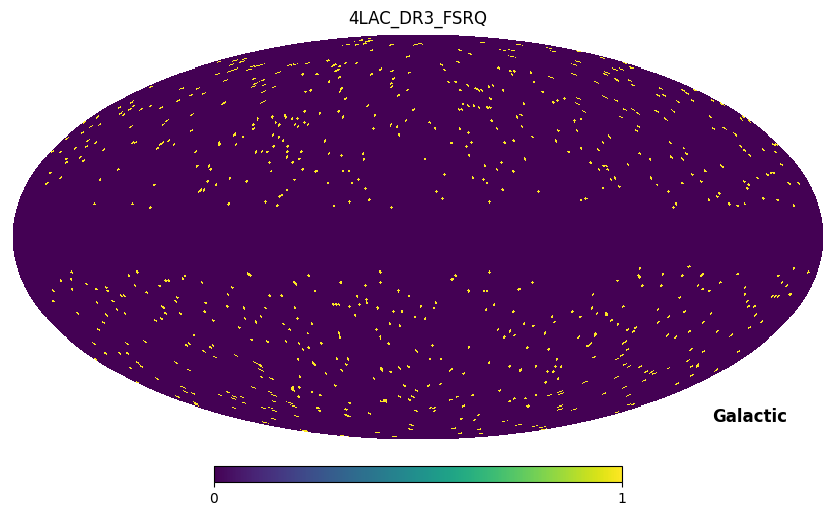

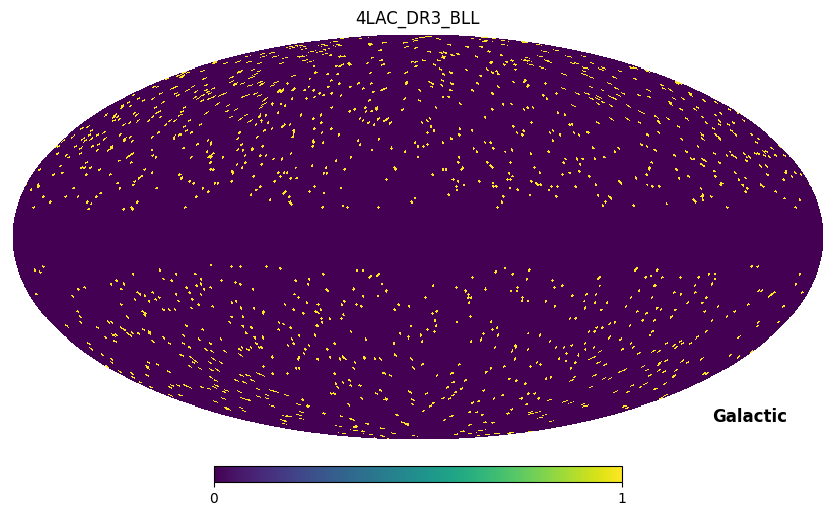

In [3]:
sky_plotter('4LAC_DR3_FSRQ.fits', 64)
sky_plotter('4LAC_DR3_BLL.fits', 64)

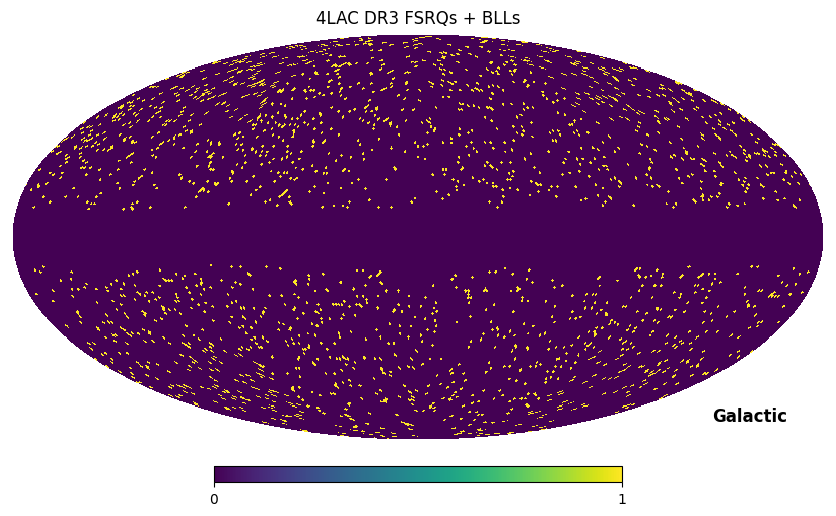

In [4]:
fsrq_map = hp.read_map('4LAC_DR3_FSRQ_map.fits')
bll_map = hp.read_map('4LAC_DR3_BLL_map.fits')
hp.mollview(fsrq_map | bll_map, title = '4LAC DR3 FSRQs + BLLs', coord = 'G')

In [5]:
fsrq_gal_coords = np.load("4LAC_DR3_FSRQ_gal_coords.npy")
bll_gal_coords = np.load("4LAC_DR3_BLL_gal_coords.npy")
coords = np.concatenate((fsrq_gal_coords, bll_gal_coords))

(360.0, 0.0)

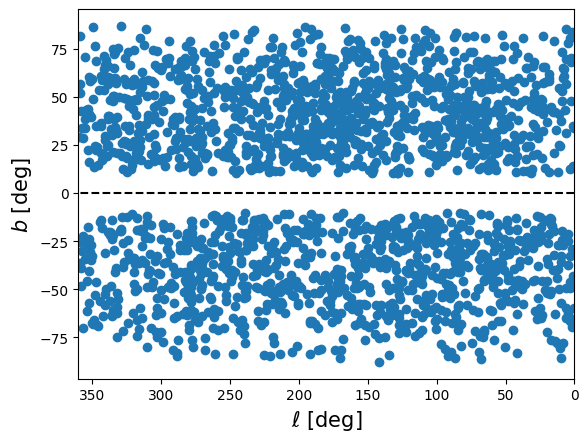

In [6]:
plt.scatter(coords[:, 0], coords[:, 1])
center = np.zeros((5, 2))
center[:, 0] = np.linspace(0., 360., 5)
plt.plot(center[:, 0], center[:, 1], linestyle = '--', color = 'k')
plt.xlabel(r'$\ell$' + ' [deg]', fontsize = 15)
plt.ylabel(r'$b$' + ' [deg]', fontsize = 15)
plt.xlim(360, 0)

In [51]:
min_dist_arr = []

for p1 in center:
    min_dist = np.inf
    
    for p2 in tqdm(coords):
        dist =  np.sqrt(((p1[0] - p2[0]) ** 2) + ((p1[1] - p2[1]) ** 2))

        if dist < min_dist:
            min_dist = dist 
        
    min_dist_arr.append(min_dist)

100%|██████████| 2134/2134 [00:00<00:00, 389666.73it/s]


In [52]:
dist = round(min(min_dist_arr))
print(dist)

11


(360.0, 0.0)

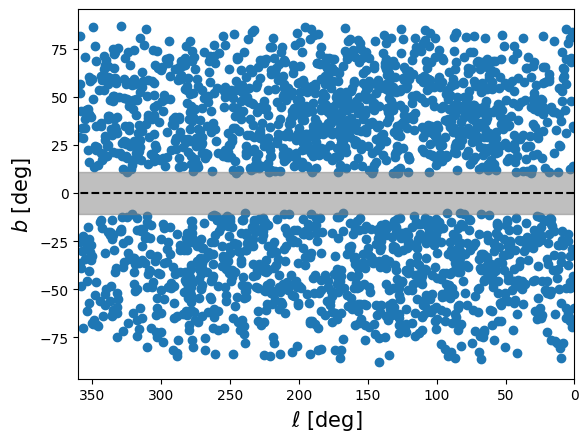

In [53]:
plt.scatter(coords[:, 0], coords[:, 1])
plt.plot(center[:, 0], center[:, 1], linestyle = '--', color = 'k')
plt.fill_between(center[:, 0], np.ones((len(center),)) * (-dist), np.ones((len(center),)) * dist, alpha = 0.5, color = 'grey')
plt.xlabel(r'$\ell$' + ' [deg]', fontsize = 15)
plt.ylabel(r'$b$' + ' [deg]', fontsize = 15)
plt.xlim(360, 0)

In [56]:
min_l = min(coords[:, 0])
print('min l:', min_l)
max_l = max(coords[:, 0])
print('max l:', max_l)
min_b = min(coords[:, 1])
print('min b:', min_b)
max_b = max(coords[:, 1])
print('max b:', max_b)

min l: 0.1552646831622595
max l: 359.90082249798337
min b: -87.68008956731327
max b: 86.76989229909942


In [63]:
randoms = np.empty((1380 * 50, 2)) # 50 times as many randoms as BLLs. For simplicity, we generate randoms from the union of both catalogues
n_success = 0 

while n_success < 1380 * 50:
    sin_p1 = np.random.uniform(-1, 1, 1)
    p1 = (np.arcsin(sin_p1) * 180 / np.pi)[0] 

    if (min_b < p1 < -dist) or (dist < p1 < max_b):
        p0 = np.random.uniform(0., 360., 1)[0]

        if min_l < p0 < max_l:
            randoms[n_success, 0] = p0
            randoms[n_success, 1] = p1
            n_success += 1

(360.0, 0.0)

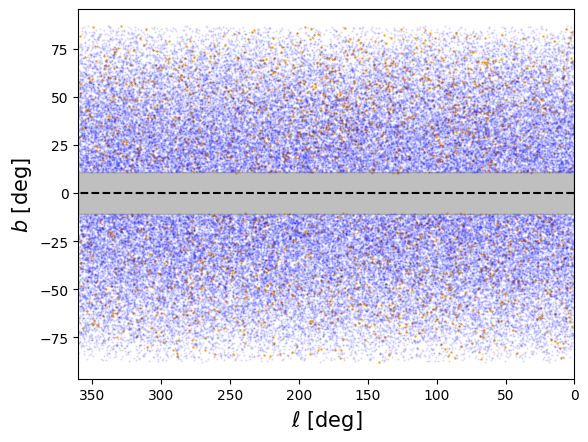

In [64]:
plt.scatter(coords[:, 0], coords[:, 1], s = 0.5, color = 'orange')
plt.plot(center[:, 0], center[:, 1], linestyle = '--', color = 'k')
plt.fill_between(center[:, 0], np.ones((len(center),)) * (-dist), np.ones((len(center),)) * dist, alpha = 0.5, color = 'grey')
plt.scatter(randoms[:, 0], randoms[:, 1], s = 0.5, alpha = 0.1, color = 'blue')
plt.xlabel(r'$\ell$' + ' [deg]', fontsize = 15)
plt.ylabel(r'$b$' + ' [deg]', fontsize = 15)
plt.xlim(360, 0)

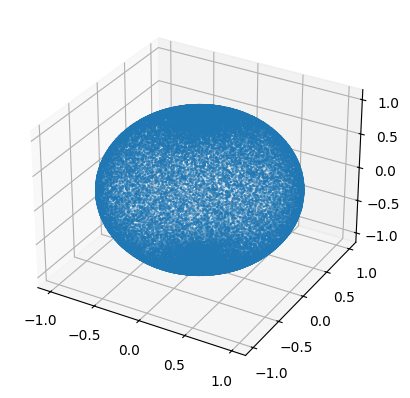

In [66]:
r = 1.
x = r * np.sin(randoms[:, 0]) * np.cos(randoms[:, 1])
y = r * np.sin(randoms[:, 0]) * np.sin(randoms[:, 1])
z = r * np.cos(randoms[:, 0])

fig = plt.figure()
ax = plt.axes(projection = '3d')
ax.scatter(x, y, z, s = 0.1)

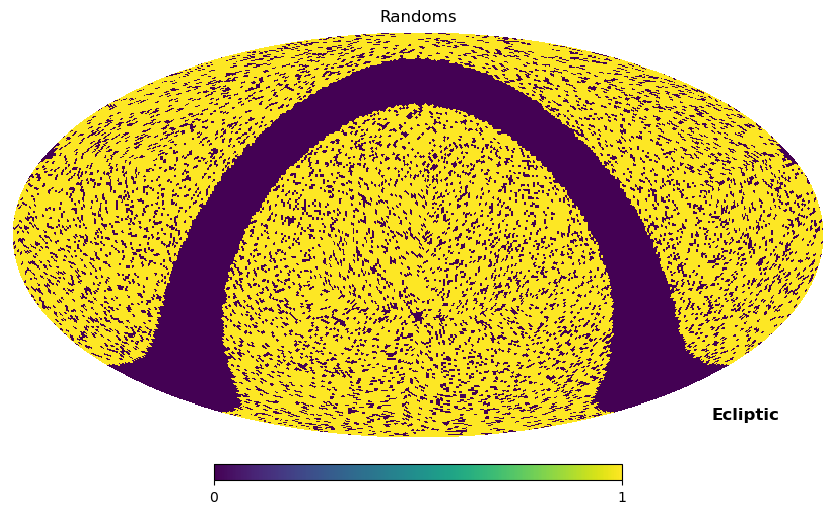

In [52]:
nside = 64
pix = hp.pixelfunc.ang2pix(nside, randoms[:, 0], randoms[:, 1], lonlat = True)
npix = hp.nside2npix(nside)
map_ = np.zeros(npix)
map_.dtype = 'int'
map_[pix] = int(1)
hp.mollview(map_, title = 'Randoms', coord = 'GE') # Appears uniform over the sphere! 
#plt.savefig('randoms.png', dpi = 400, bbox_inches = 'tight')

In [15]:
randoms_ = np.empty(randoms.shape)
gal_coords = SkyCoord(l = randoms[:, 0] * u.degree, b = randoms[:, 1] * u.degree, frame = 'galactic')
randoms_[:, 0] = gal_coords.icrs.ra.to(u.deg).value # Convert back to RA and Dec for pycorr 
randoms_[:, 1] = gal_coords.icrs.dec.to(u.deg).value

In [54]:
rand_t = Table()
rand_t['ra'] = randoms_[:, 0]
rand_t['dec'] = randoms_[:, 1]
rand_t.write('randoms.fits', format = 'fits', overwrite = True)

Moving on to $w(\theta)$...

In [68]:
wtheta_fsrq = np.load('wtheta_fsrq.npy', allow_pickle = True).ravel()[0]
wtheta_bll = np.load('wtheta_bll.npy', allow_pickle = True).ravel()[0]
wtheta_cross = np.load('wtheta_cross.npy', allow_pickle = True).ravel()[0]

In [69]:
def wtheta_dvecs(pycorr_jk_obj):
    sep = pycorr_jk_obj.sep[1:] # For some reason the 1st data point is always weird with pycorr
    wtheta = pycorr_jk_obj.corr[1:]
    dvecs = []

    for i in pycorr_jk_obj.realizations:
        dvecs.append(pycorr_jk_obj.realization(i).corr[1:])

    cov = np.cov(dvecs, rowvar = False, bias = True) * (len(pycorr_jk_obj.realizations) - 1)
    err = np.sqrt(cov.diagonal())

    res = np.empty((len(sep),3))
    res[:, 0] = sep
    res[:, 1] = wtheta
    res[:, 2] = err

    return res 

In [70]:
fsrq_arr = wtheta_dvecs(wtheta_fsrq)
bll_arr = wtheta_dvecs(wtheta_bll)
cross_arr = wtheta_dvecs(wtheta_cross)

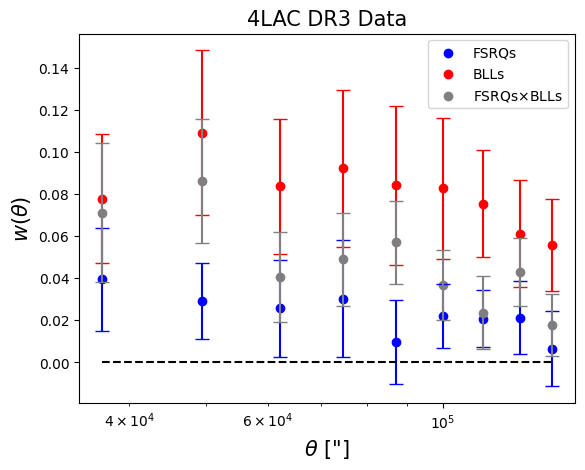

In [71]:
plt.scatter(fsrq_arr[:, 0] * 3600, fsrq_arr[:, 1], color = 'blue', label = 'FSRQs')
plt.errorbar(fsrq_arr[:, 0] * 3600, fsrq_arr[:, 1], yerr = fsrq_arr[:, 2], linestyle = '', capsize = 5, color = 'blue')
plt.scatter(bll_arr[:, 0] * 3600, bll_arr[:, 1], color = 'red', label = 'BLLs')
plt.errorbar(bll_arr[:, 0] * 3600, bll_arr[:, 1], yerr = bll_arr[:, 2], linestyle = '', capsize = 5, color = 'red')
plt.scatter(cross_arr[:, 0] * 3600, cross_arr[:, 1], color = 'grey', label = 'FSRQs' + r'$\times$' + 'BLLs')
plt.errorbar(cross_arr[:, 0] * 3600, cross_arr[:, 1], yerr = cross_arr[:, 2], linestyle = '', capsize = 5, color = 'grey')
plt.hlines(0, min(fsrq_arr[:, 0] * 3600), max(fsrq_arr[:, 0] * 3600), linestyle = '--', color = 'k')
plt.xscale('log')
plt.title('4LAC DR3 Data', fontsize = 15)
plt.xlabel(r'$\theta$' + ' ["]', fontsize = 15)
plt.ylabel(r'$w(\theta)$', fontsize = 15)
plt.legend(loc = 'best')
#plt.savefig('4LAC_DR3_wtheta.png', dpi = 400, bbox_inches = 'tight')